# Optimizing String Dynamics in Time with a Differentiable ODE solver

This example shows how to use the differentiable ODEs to learn nonlinear string dynamics, we can optionally replace the nonlinear function in the Störmer-Verlet integration scheme with a learnable neural network, therefore becoming a Neural ODE.

In [1]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import scienceplots  # noqa: F401
from IPython.display import Audio, display
from jaxtyping import Array, ArrayLike, Float
from tqdm import tqdm

from jaxdiffmodal.excitations import create_pluck_modal
from jaxdiffmodal.ftm import (
    evaluate_string_eigenfunctions,
    string_eigenvalues,
    StringParameters,
)
from jaxdiffmodal.time_integrators import (
    solve_sv_ic,
    string_tau_with_density,
)


plt.style.use(["ieee", "no-latex"])
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.fancybox"] = True

# Utilities

In [2]:
def create_static_filter(
    model,
    static_params_lambda,
):
    is_static_filter = jax.tree_util.tree_map(lambda _: False, model)

    selected_params = static_params_lambda(model)

    if isinstance(selected_params, tuple):
        true_values = tuple(True for _ in selected_params)
    else:
        # Single parameter case
        true_values = True

    is_static_filter = eqx.tree_at(
        static_params_lambda,
        is_static_filter,
        true_values,
    )
    return is_static_filter


def visualize_results(
    model,
    time: Array,
    n_steps_vis: int,
    n_steps_train: int,
    dt: float,
    n_modes: int,
    losses: Array | None = None,
):
    """Visualize training results and model predictions."""
    print("Generating visualizations...")

    time_test = jnp.arange(n_steps_vis) * dt

    # Get modal trajectories for visualization
    targ_test_traj_modal: Array = gt_model(
        n_steps=n_steps_vis,
        dt=dt,
        n_modes=n_modes,
        return_modal=True,
    )

    pred_test_traj_modal = model(
        n_steps=n_steps_vis,
        dt=dt,
        n_modes=n_modes,
        return_modal=True,
    )

    pred_test_traj_phys: Array = model(
        n_steps=n_steps_vis,
        dt=dt,
        n_modes=n_modes,
        return_modal=False,
    )

    # Target physical position
    targ_test_traj_phys: Array = targ_test_traj_position

    # Check if losses exist and training is complete
    plot_losses = losses is not None and len(losses) > 0

    # Create plots - adjust subplot layout based on whether we're plotting losses
    if plot_losses:
        fig = plt.figure(figsize=(15, 10))
        gs_main = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        # Plot loss in bottom right when training is complete
        loss_ax = fig.add_subplot(gs_main[1, 1])
        loss_ax.semilogy(losses)
        loss_ax.set_title("Training Loss")
        loss_ax.set_xlabel("Epoch")
        loss_ax.set_ylabel("MSE Loss")
        loss_ax.grid(True)
    else:
        fig = plt.figure(figsize=(15, 5))
        gs_main = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)

    # Plot 1: Physical space comparison
    physical_ax = fig.add_subplot(gs_main[0, 0])
    physical_ax.plot(
        time_test[:n_steps_vis],
        targ_test_traj_phys[:n_steps_vis],
        "b-",
        label="Target",
    )
    physical_ax.plot(
        time_test[:n_steps_vis],
        pred_test_traj_phys[:n_steps_vis],
        "r--",
        label="Neural ODE",
    )
    physical_ax.set_title("Physical Space Displacement")
    physical_ax.set_xlabel("Time (s)")
    physical_ax.set_ylabel("Displacement (m)")
    physical_ax.set_ylim(-0.0025, 0.0025)
    physical_ax.grid(True)
    physical_ax.axvline(
        x=n_steps_train * dt,
        color="k",
        alpha=1.0,
        label="Train/Test Split",
    )
    physical_ax.legend(loc="upper right")

    # Plot 2: Modal amplitudes comparison - use the right half of top row
    if plot_losses:
        # Create subplot within the top-right area, avoiding the loss plot
        modal_gs = gs_main[0, 1].subgridspec(3, 1, hspace=0.4)
    else:
        # Use the right half for modal plots
        modal_gs = gs_main[0, 1].subgridspec(3, 1, hspace=0.4)

    for mode_idx in range(min(3, n_modes)):
        modal_ax = fig.add_subplot(modal_gs[mode_idx, 0])
        modal_ax.plot(
            time_test,
            targ_test_traj_modal[:n_steps_vis, mode_idx],
            label="Target",
            alpha=0.8,
            linewidth=1.5,
        )
        modal_ax.plot(
            time_test,
            pred_test_traj_modal[:n_steps_vis, mode_idx],
            "--",
            label="Prediction",
            alpha=0.8,
            linewidth=1.5,
        )
        modal_ax.set_title(f"Mode {mode_idx + 1}", fontsize=10)
        if mode_idx == 2:  # Only bottom plot gets x-label
            modal_ax.set_xlabel("Time (s)", fontsize=9)
        modal_ax.set_ylabel("Amplitude", fontsize=9)
        modal_ax.set_ylim(-0.0083, 0.0083)
        modal_ax.tick_params(labelsize=8)
        if mode_idx == 0:  # Only top plot gets legend
            modal_ax.legend(fontsize=8)
        modal_ax.grid(True, alpha=0.3)
        modal_ax.axvline(
            x=n_steps_train * dt,
            color="k",
            alpha=0.7,
            linestyle=":",
        )

    plt.show()

## Step 1: Generate Synthetic String Data

First, we'll create synthetic string data using jaxdiffmodal's physical model.
We'll generate both linear and nonlinear dynamics to have target data for training.


In [3]:

n_modes: int = 15
sample_rate: int = 16000
dt: float = 1.0 / sample_rate
n_steps_train: int = 1000
n_steps_test: int = 16000
n_steps_vis = 2000

In [4]:

string_params = StringParameters()
indices = jnp.arange(n_modes) + 1

lambda_mu = string_eigenvalues(
    n_modes,
    string_params.length,
)
exc = create_pluck_modal(
    lambdas=lambda_mu,
    string_length=string_params.length,
    initial_deflection=0.03,
)

weights = evaluate_string_eigenfunctions(
    indices=indices,
    position=jnp.array(0.6),
    params=string_params,
)

u0 = jnp.array(exc)
v0 = jnp.zeros_like(u0)
time = jnp.arange(n_steps_train) * dt


class StringModel(eqx.Module):
    length: ArrayLike
    d3_with_density: ArrayLike
    log_Ts0_with_density: ArrayLike
    bending_stiffness_with_density: ArrayLike
    tau_with_density: ArrayLike
    v0: Array
    u0: Array
    weights: Array  # Modal weights for single position output
    mlp: eqx.Module | None = None

    def __call__(
        self,
        n_steps: int,
        dt: float,
        n_modes: int = 10,
        return_modal: bool = False,
    ) -> Float[Array, " n_steps"] | Float[Array, "n_steps n_modes"]:
        # Unpack parameters
        length: ArrayLike = self.length
        d3_with_density: ArrayLike = self.d3_with_density
        # Convert from log-space
        Ts0_with_density: ArrayLike = jnp.exp(self.log_Ts0_with_density)
        bending_stiffness_with_density: ArrayLike = self.bending_stiffness_with_density
        tau_with_density: ArrayLike = self.tau_with_density
        u0: Array = self.u0
        v0: Array = self.v0

        # get the analytical eigenvalues
        lambda_mu: Array = string_eigenvalues(
            n_modes,
            length,
        )

        # get the damping and stiffness terms
        omega_mu_squared: Array = (
            bending_stiffness_with_density * lambda_mu**2 + Ts0_with_density * lambda_mu
        )
        gamma2_mu: Array = d3_with_density * lambda_mu

        # calculate the factor for the nonlinear term
        string_norm: float = string_params.length / 2
        string_tau: Array = tau_with_density * lambda_mu / string_norm

        def nl_fn(q: ArrayLike) -> Array:
            return lambda_mu * q * (string_tau @ q**2)

        def nl_fn_nn(q: ArrayLike) -> Array:
            return lambda_mu * self.mlp(q)

        _, traj = solve_sv_ic(
            gamma2_mu=gamma2_mu,
            omega_mu_squared=omega_mu_squared,
            u0=u0,
            v0=v0,
            dt=dt,
            n_steps=n_steps,
            nl_fn=nl_fn_nn if self.mlp is not None else nl_fn,
        )

        if return_modal:
            return traj
        else:
            # Apply weights to get single position output
            return traj @ self.weights

In [5]:

string_tau: float = string_tau_with_density(string_params)

gt_model = StringModel(
    length=string_params.length,
    log_Ts0_with_density=jnp.log(string_params.Ts0 / string_params.density),
    d3_with_density=(string_params.d3 / string_params.density),
    bending_stiffness_with_density=(
        string_params.bending_stiffness / string_params.density
    ),
    tau_with_density=string_tau_with_density(string_params),
    u0=u0,
    v0=v0,
    weights=weights,
    mlp=None,
)


# Get weighted trajectory at single position for training target
targ_test_traj_position: Array = gt_model(
    n_steps=n_steps_test,
    dt=dt,
    n_modes=n_modes,
    return_modal=False,
)

# slice a section for training
targ_train_traj_position: Array = targ_test_traj_position[:n_steps_train]

In [6]:

# Initialize model with random weights for optimization
key = jax.random.PRNGKey(12345)
(
    key_len,
    key_Ts0,
    key_d3,
) = jax.random.split(key, 3)

model = StringModel(
    length=jax.random.uniform(
        shape=(1,),
        minval=0.6,
        maxval=0.8,
        key=key_len,
    ),
    log_Ts0_with_density=jax.random.uniform(
        shape=(1,),
        minval=jnp.log(10_000),
        maxval=jnp.log(80_000),
        key=key_Ts0,
    ),
    d3_with_density=jax.random.uniform(
        shape=(1,),
        minval=5.0,
        maxval=7.0,
        key=key_d3,
    ),
    bending_stiffness_with_density=(
        string_params.bending_stiffness / string_params.density
    ),
    tau_with_density=string_tau_with_density(string_params),
    u0=u0,
    v0=v0,
    weights=weights,
    mlp=None,
)

# Create the static filter using the wrapper function
is_static_filter = create_static_filter(
    model=model,
    static_params_lambda=lambda m: (
        m.v0,
        m.u0,
        m.weights,
        m.bending_stiffness_with_density,
    ),
)

# Now, partition the model using our custom filter
static_model, diff_model = eqx.partition(
    model,
    is_static_filter,
)

pred_init_traj_position = model(
    n_steps=n_steps_test,
    dt=dt,
    n_modes=n_modes,
    return_modal=False,
)

display(Audio(targ_test_traj_position, rate=sample_rate))
display(Audio(pred_init_traj_position, rate=sample_rate))

Define the training loop and loss function.

In [7]:
def save_animation_frame(
    model,
    time: Array,
    weights: Array,
    frame_idx: int,
    gt_model,
    output_dir: str = "tmp_node",
):
    Path(output_dir).mkdir(exist_ok=True, parents=True)

    time_test = jnp.arange(n_steps_test) * dt

    pred_test_traj_modal = model(
        n_steps=n_steps_test,
        dt=dt,
        n_modes=n_modes,
        return_modal=True,
    )

    pred_test_traj_phys: Array = model(
        n_steps=n_steps_test,
        dt=dt,
        n_modes=n_modes,
        return_modal=False,
    )

    # Target physical position
    targ_test_traj_phys: Array = targ_test_traj_position

    # Create figure with centered plot and table underneath
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.4)

    # Plot 1: Physical space comparison (centered)
    physical_ax = fig.add_subplot(gs[0, 0])
    physical_ax.plot(
        time_test[: n_steps_vis * 2],
        targ_test_traj_phys[: n_steps_vis * 2],
        "b-",
        label="Target",
    )
    physical_ax.plot(
        time_test[: n_steps_vis * 2],
        pred_test_traj_phys[: n_steps_vis * 2],
        "r--",
        label="Optim",
    )
    physical_ax.set_title("Physical Space Displacement")
    physical_ax.set_xlabel("Time (s)")
    physical_ax.set_ylabel("Displacement (m)")
    physical_ax.set_ylim(-0.0025, 0.0025)
    physical_ax.legend(loc="upper right")
    physical_ax.grid(True)
    physical_ax.axvline(
        x=n_steps_train * dt,
        color="k",
        linestyle=":",
        alpha=0.7,
        label="Train/Test Split",
    )

    # Add parameter table
    table_ax = fig.add_subplot(gs[1, 0])
    table_ax.axis("off")

    # Create table data - handle both JAX arrays and floats
    def format_param(param):
        return param.item() if hasattr(param, "item") else param

    table_data = [
        ["Parameter", "Current", "Ground Truth"],
        [
            "Length",
            f"{format_param(model.length):.4f}",
            f"{format_param(gt_model.length):.4f}",
        ],
        [
            r"$\hat{d}_3$",
            f"{format_param(model.d3_with_density):.6f}",
            f"{format_param(gt_model.d3_with_density):.6f}",
        ],
        [
            r"$\hat{T}_0$",
            # Show actual value, not log
            f"{format_param(jnp.exp(model.log_Ts0_with_density)):.1f}",
            f"{format_param(jnp.exp(gt_model.log_Ts0_with_density)):.1f}",
        ],
    ]

    table = table_ax.table(
        cellText=table_data,
        cellLoc="center",
        loc="center",
        colWidths=[0.25, 0.25, 0.25],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)

    # Style the header row
    for i in range(len(table_data[0])):
        table[(0, i)].set_facecolor("#40466e")
        table[(0, i)].set_text_props(weight="bold", color="white")

    plt.tight_layout()
    plt.savefig(f"{output_dir}/frame_{frame_idx:05d}.png", dpi=150, bbox_inches="tight")
    plt.close()

In [8]:
def train_neural_ode(
    model,
    save_frames=False,
    frame_interval=50,
):
    print("Training...")

    # normalise target trajectory for better training stability
    # Now using single position target instead of modal trajectories
    scale: float = jnp.max(jnp.abs(targ_train_traj_position)).item()
    targ_train_traj_position_scaled = targ_train_traj_position / scale

    @eqx.filter_jit
    def training_step(
        model,
        optimizer,
        opt_state,
        targ_train_traj_position_scaled,
    ):
        @eqx.filter_value_and_grad
        def loss_fn(
            diff_model,
            static_model,
            targ_train_traj_position_scaled,
        ):
            model: eqx.Module = eqx.combine(diff_model, static_model)

            pred_train_traj_position: Array = model(
                n_steps=n_steps_train,
                dt=dt,
                n_modes=n_modes,
                return_modal=False,
            )

            pred_train_traj_position: Array = (
                pred_train_traj_position / scale
            )  # normalise predictions

            # MSE loss
            mse_loss = jnp.mean(
                (pred_train_traj_position - targ_train_traj_position_scaled) ** 2
            )

            total_loss = mse_loss

            return total_loss

        static_model, diff_model = eqx.partition(
            model,
            is_static_filter,
        )
        loss_value, grads = loss_fn(
            diff_model,
            static_model,
            targ_train_traj_position_scaled,
        )

        updates, opt_state = optimizer.update(grads, opt_state)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    # Training setup
    epochs = 10000
    learning_rate = 1e-4
    schedule = optax.cosine_onecycle_schedule(
        transition_steps=epochs,
        peak_value=learning_rate,
    )
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adabelief(schedule),
    )
    opt_state = optimizer.init(
        eqx.filter(model, eqx.is_array),
    )

    losses = []

    bar = tqdm(range(epochs))
    for epoch in bar:
        model, opt_state, loss_value = training_step(
            model,
            optimizer,
            opt_state,
            targ_train_traj_position_scaled,
        )
        losses.append(loss_value)

        # Early stopping if NaN detected or loss explodes
        if jnp.isnan(loss_value) or loss_value > 1e8:
            print(
                f"\nWarning: Training stopped early at epoch {epoch + 1} due to instability"
            )
            print(f"Loss value: {loss_value}")
            break

        bar.set_description(f"Epoch {epoch + 1}/{epochs} | Loss: {loss_value:.6f}")

        # Save animation frame periodically
        if save_frames and epoch % frame_interval == 0:
            save_animation_frame(
                model=model,
                time=time,
                weights=weights,
                frame_idx=epoch // frame_interval,
                gt_model=gt_model,
            )

    return model, losses

Generating visualizations...


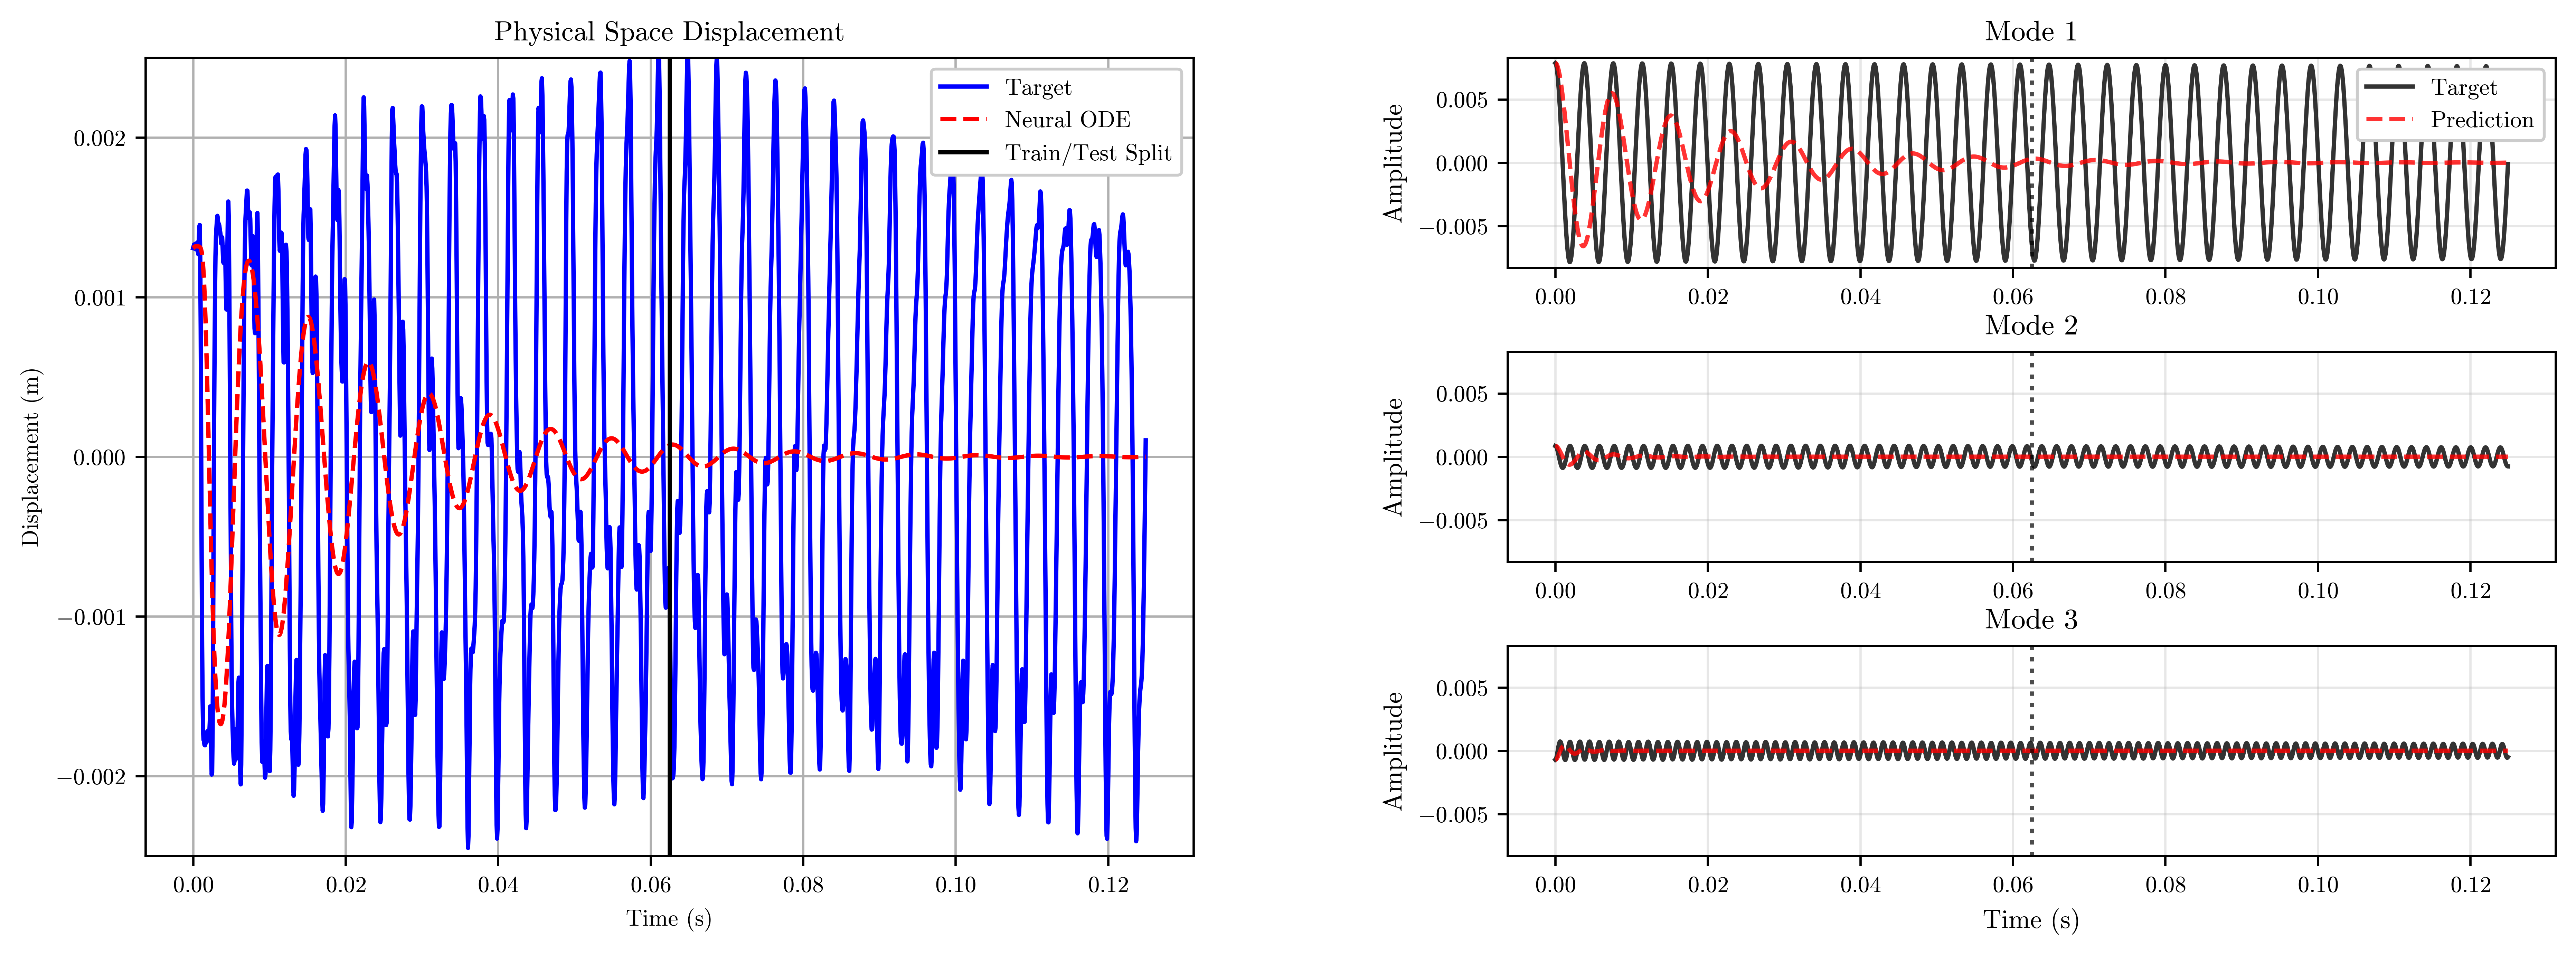

In [10]:
# First visualisation of the initial model
visualize_results(
    model=model,
    time=time,
    n_steps_vis=n_steps_vis,
    n_steps_train=n_steps_train,
    dt=dt,
    n_modes=n_modes
)

In [11]:
print("Starting training...")
trained_model, training_losses = train_neural_ode(
    model,
    save_frames=False,
    frame_interval=100,
)
print(f"Training completed! Final loss: {training_losses[-1]:.6f}")

Starting training...
Training...


Epoch 10000/10000 | Loss: 0.000000: 100%|██████████| 10000/10000 [00:24<00:00, 402.16it/s]

Training completed! Final loss: 0.000000


Generating visualizations...


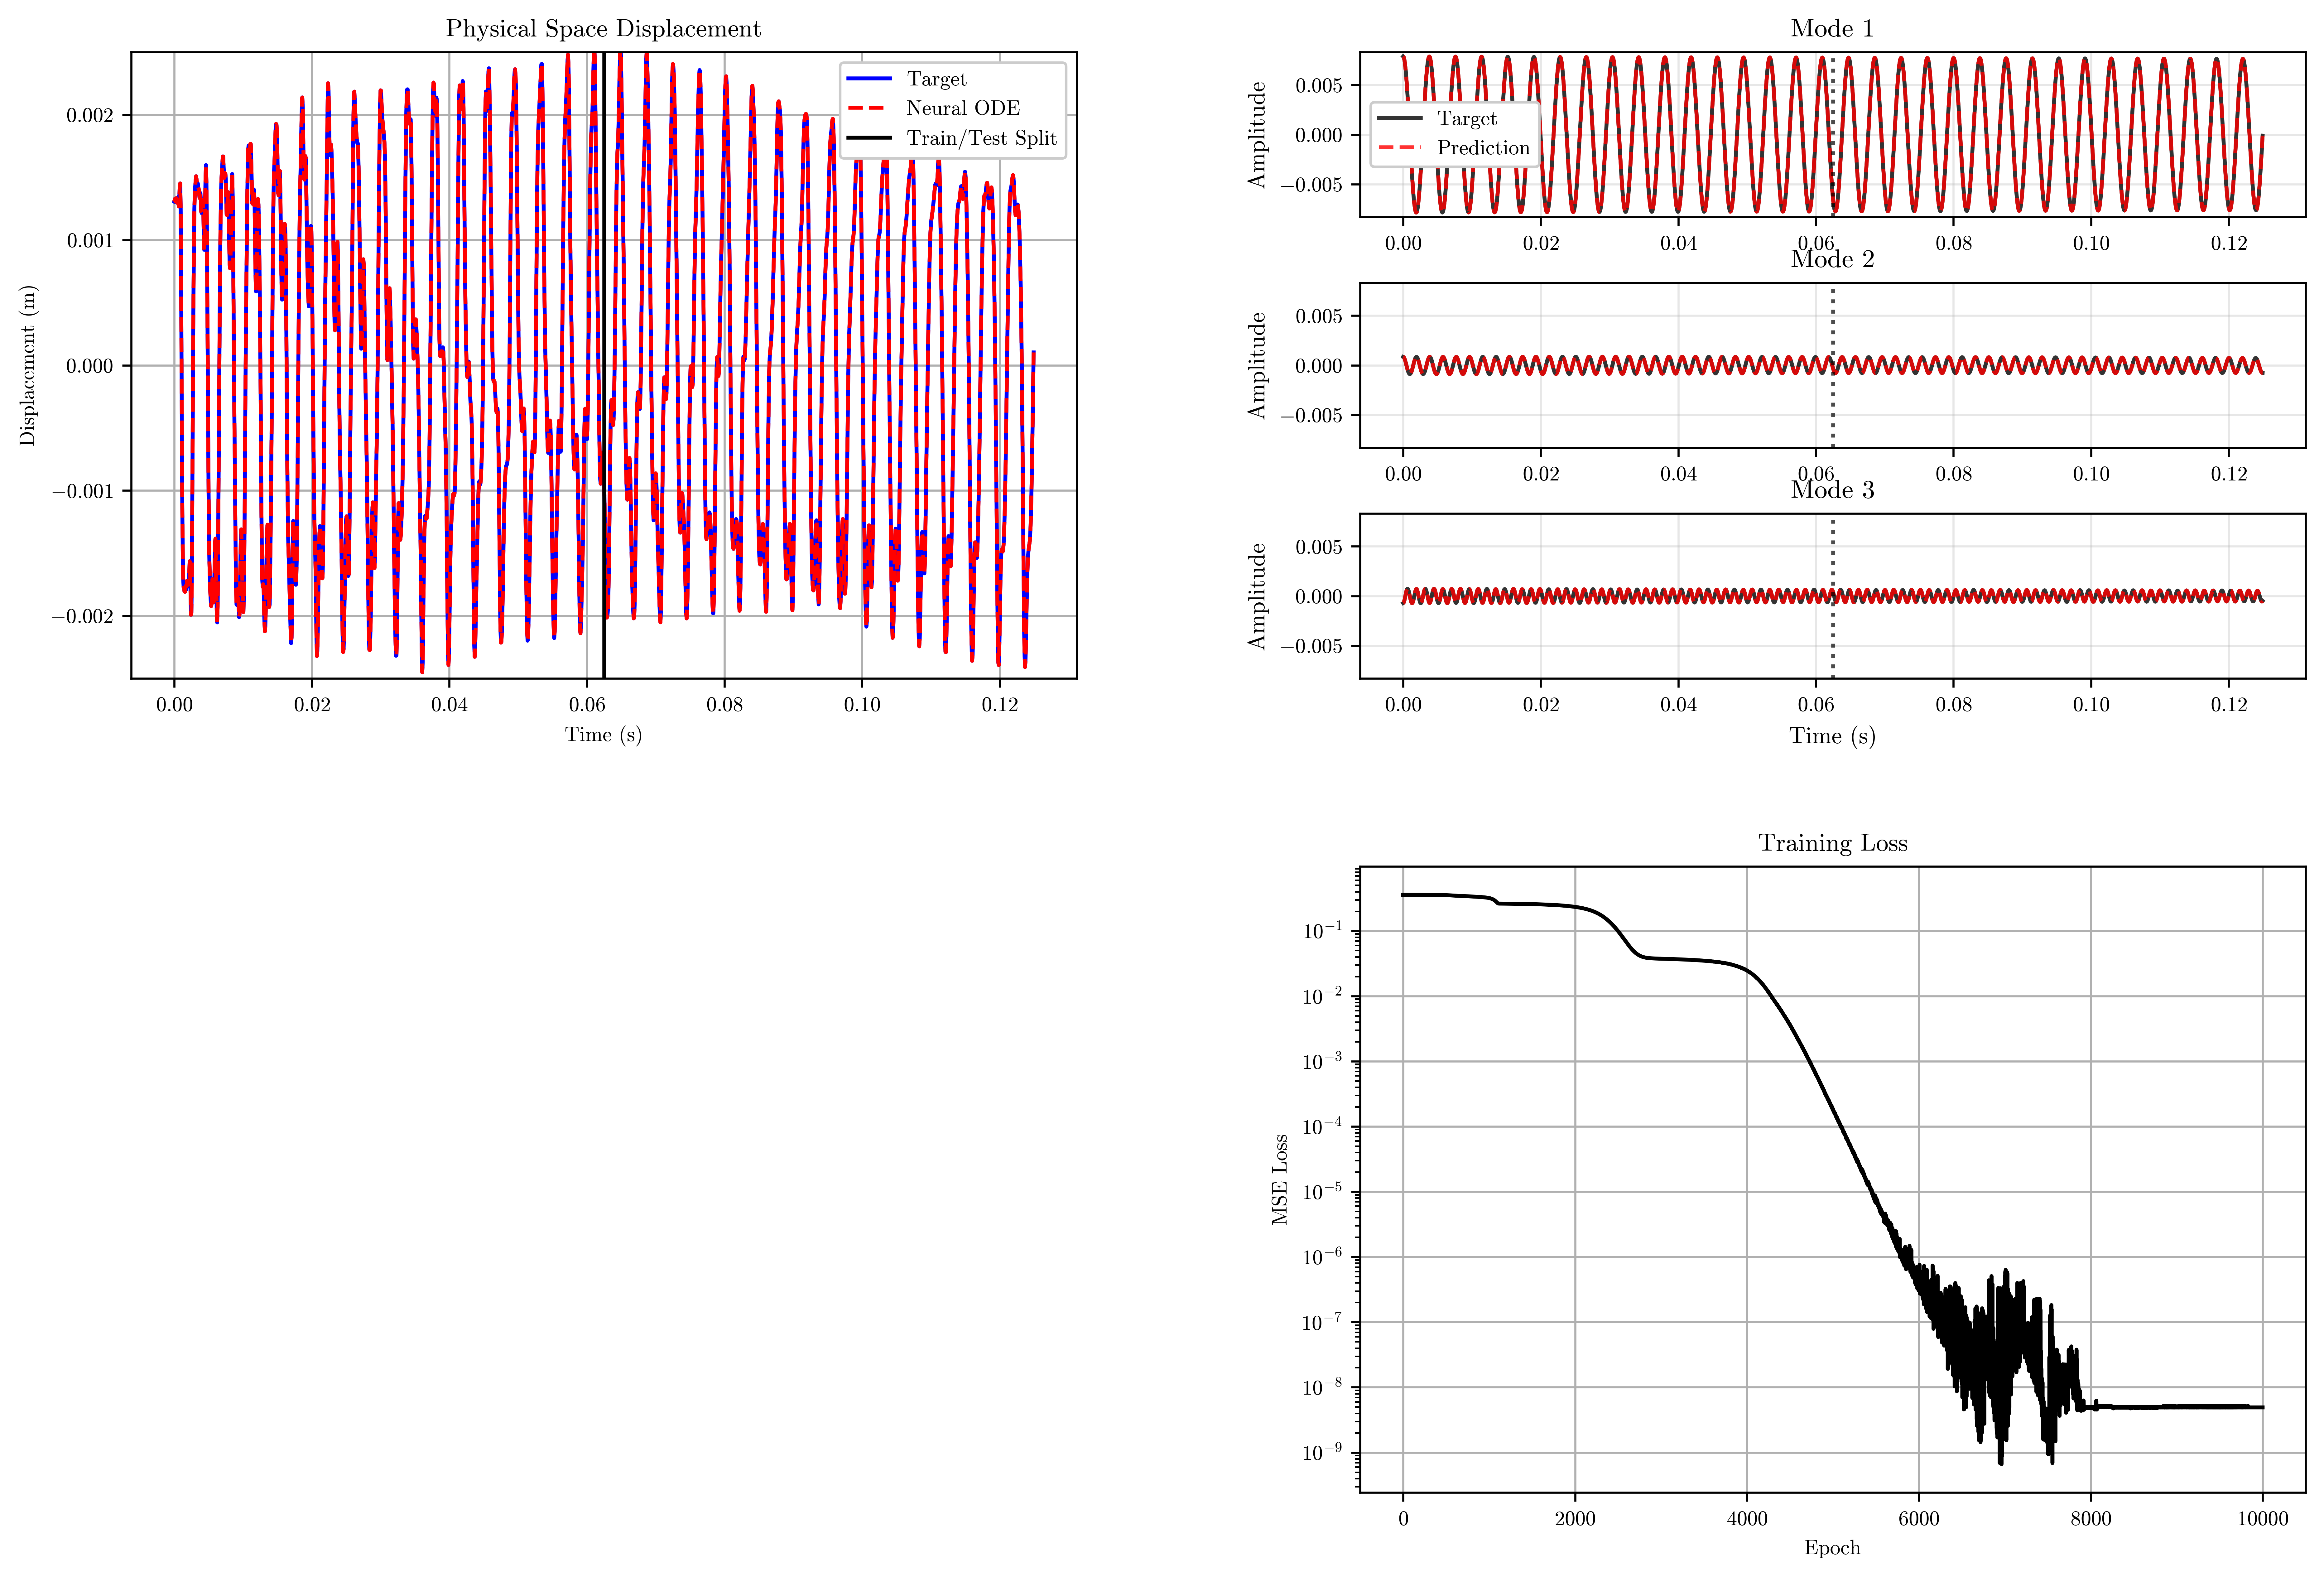

In [13]:
visualize_results(
    model=trained_model,
    time=time,
    losses=training_losses,
    n_steps_vis=n_steps_vis,
    n_steps_train=n_steps_train,
    dt=dt,
    n_modes=n_modes
)